# Road Traffic Accidents in Ethiopia — Week 2: Data Loading and Understanding

**Project Title:** Analyzing Road Traffic Accidents in Ethiopia

**Problem Statement:** Road traffic accidents (RTAs) are a major public health and safety concern in Ethiopia. This project analyzes a dataset of recorded traffic accidents to understand the conditions, driver behaviors, and environmental factors most associated with accident severity, in order to support road safety planning and policy decisions.

**Target Users:** Road safety authorities, traffic police, urban planners, and insurance companies.

**Dataset:** `RTA Dataset .csv` — Road Traffic Accident records from Addis Ababa, Ethiopia.

---
This notebook covers the **Week 2** deliverables: loading the dataset with Pandas and performing an initial exploration of its structure, data types, missing values, duplicates, and summary statistics.

In [14]:
packages= ["pandas>=2.2.0",
           "numpy>=2.0.0",
           "matplotlib>=3.9.0",
           "seaborn>=0.13.2",
           "jupyter>=1.1.0",
           "notebook>=7.0.0"]

with open("../requirements.txt", "w") as file: #..\requirements- creates the txt file one folder up from where the current notebook is in
    file.write("\n".join(packages))

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Display settings so wide dataframes are easier to read in the notebook

## 1. Load the Dataset

In [16]:
#loading of the dataset
df = pd.read_csv(r"C:\Users\User\Downloads\traffic_accidents_ ethiopia\RTA Dataset.csv")
#print("Dataset loaded successfully.")

## 2. Preview the Data

In [17]:
# First 5 rows
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,NaN,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,No defect,Recreational areas,other,NaN,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,No defect,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,No defect,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [18]:
# Last 5 rows
df.tail()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
12311,16:15:00,Wednesday,31-50,Male,NaN,Employee,2-5yr,Lorry (11?40Q),Owner,NaN,No defect,Outside rural areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,1,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12312,18:00:00,Sunday,Unknown,Male,Elementary school,Employee,5-10yr,Automobile,Owner,NaN,No defect,Outside rural areas,Two-way (divided with broken lines road marking),Escarpments,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,1,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12313,13:55:00,Sunday,Over 51,Male,Junior high school,Employee,5-10yr,Bajaj,Owner,2-5yrs,No defect,Outside rural areas,Two-way (divided with broken lines road marking),Tangent road with mountainous terrain and,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,1,1,Other,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Serious Injury
12314,13:55:00,Sunday,18-30,Female,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,2-5yrs,No defect,Office areas,Undivided Two way,Tangent road with mountainous terrain and,No junction,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,1,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,Driving under the influence of drugs,Slight Injury
12315,13:55:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Other,Owner,2-5yrs,No defect,Outside rural areas,Undivided Two way,Tangent road with mountainous terrain and,O Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,1,Stopping,Pedestrian,Female,5,3,Driver,Normal,Crossing from nearside - masked by parked or s...,Changing lane to the right,Slight Injury


## 3. Dataset Shape (Rows and Columns)

In [19]:
#dataset shape
rows, cols = df.shape
print("Number of rows:", rows)
print("Number of columns:",cols)

Number of rows: 12316
Number of columns: 32


## 4. Column Names

In [20]:
columns = df.columns
for index, col in enumerate(columns, start=1): # enumerate is generating a sequence of column names paired up with their index numbers.
    print(f"{index}.{col}")
    # print(str(index) + "." + col)

1.Time
2.Day_of_week
3.Age_band_of_driver
4.Sex_of_driver
5.Educational_level
6.Vehicle_driver_relation
7.Driving_experience
8.Type_of_vehicle
9.Owner_of_vehicle
10.Service_year_of_vehicle
11.Defect_of_vehicle
12.Area_accident_occured
13.Lanes_or_Medians
14.Road_allignment
15.Types_of_Junction
16.Road_surface_type
17.Road_surface_conditions
18.Light_conditions
19.Weather_conditions
20.Type_of_collision
21.Number_of_vehicles_involved
22.Number_of_casualties
23.Vehicle_movement
24.Casualty_class
25.Sex_of_casualty
26.Age_band_of_casualty
27.Casualty_severity
28.Work_of_casuality
29.Fitness_of_casuality
30.Pedestrian_movement
31.Cause_of_accident
32.Accident_severity


## 5. Data Types and General Info

In [21]:
#data types 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Time                         12316 non-null  str  
 1   Day_of_week                  12316 non-null  str  
 2   Age_band_of_driver           12316 non-null  str  
 3   Sex_of_driver                12316 non-null  str  
 4   Educational_level            11575 non-null  str  
 5   Vehicle_driver_relation      11737 non-null  str  
 6   Driving_experience           11487 non-null  str  
 7   Type_of_vehicle              11366 non-null  str  
 8   Owner_of_vehicle             11834 non-null  str  
 9   Service_year_of_vehicle      8388 non-null   str  
 10  Defect_of_vehicle            7889 non-null   str  
 11  Area_accident_occured        12077 non-null  str  
 12  Lanes_or_Medians             11931 non-null  str  
 13  Road_allignment              12174 non-null  str  
 14  T

## 6. Statistical Description of the Dataset

In [22]:
# summary of all columns(for both categorical and numerical columns)
df.describe(include= "all")

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
count,12316,12316,12316,12316,11575,11737,11487,11366,11834,8388,7889,12077,11931,12174,11429,12144,12316,12316,12316,12161,12316.000000,12316.000000,12008,12316,12316,12316,12316,9118,9681,12316,12316,12316
unique,1074,7,5,3,7,4,7,17,4,6,3,14,7,9,8,5,4,4,9,10,NaN,NaN,13,4,3,6,4,7,5,9,20,3
top,15:30:00,Friday,18-30,Male,Junior high school,Employee,5-10yr,Automobile,Owner,Unknown,No defect,Other,Two-way (divided with broken lines road marking),Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,NaN,NaN,Going straight,Driver or rider,Male,na,3,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
freq,120,2041,4271,11437,7619,9627,3363,3205,10459,2883,7777,3819,4411,10459,4543,11296,9340,8798,10063,8774,NaN,NaN,8158,4944,5253,4443,7076,5903,9608,11390,2263,10415
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.040679,1.548149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.688790,1.007179,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Missing Values

In [23]:
missing_vals= df.isna().sum()
missing_percent= ((missing_vals / len(df)) * 100).round(2)

missing_summary= pd.DataFrame({
    "Missing_Count":missing_vals,
    "Missing_Percentage":missing_percent
}).sort_values(by="Missing_Count", ascending=False)

missing_summary

,Missing_Count,Missing_Percentage
Defect_of_vehicle,4427,35.95
Service_year_of_vehicle,3928,31.89
Work_of_casuality,3198,25.97
Fitness_of_casuality,2635,21.39
Type_of_vehicle,950,7.71
Types_of_Junction,887,7.20
Driving_experience,829,6.73
Educational_level,741,6.02
Vehicle_driver_relation,579,4.70
Owner_of_vehicle,482,3.91


In [24]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [25]:
# To check if there are any duplicate columns
print(df.columns.duplicated().any())

False


In [26]:
for col in columns:
    if df[col].dtype == "object":
        print(f"Unique values in {col}:",df[col].unique())
        print("\n")

In [27]:
# columns we'll be working with for this project
core_columns = ["Time",
    "Day_of_week",
    "Age_band_of_driver",
    "Sex_of_driver",
    "Driving_experience",
    "Type_of_vehicle",
    "Area_accident_occured",
    "Road_surface_type",
    "Road_surface_conditions",
    "Weather_conditions",
    "Light_conditions",
    "Type_of_collision",
    "Number_of_vehicles_involved",
    "Number_of_casualties",
    "Vehicle_movement",
    "Sex_of_casualty",
    "Age_band_of_casualty",
    "Casualty_severity",
    "Cause_of_accident",
    "Accident_severity"]

# columns we can use for future analysis
optional_columns = ["Owner_of_vehicle",
    "Service_year_of_vehicle",
    "Fitness_of_casuality",
    "Pedestrian_movement"]

df2 = df[core_columns + optional_columns].copy()

In [28]:
rows, cols = df2.shape
print("Number of rows:", rows)
print("Number of columns:",cols)

Number of rows: 12316
Number of columns: 24


## Stnadardize text
### by capitalization, spacing, spelling

In [29]:
# Remove (leading and trailing)whitespace from all object columns
object_cols = df2.select_dtypes(include="object").columns

df2[object_cols] = df2[object_cols].apply(lambda col: col.str.strip())

C:\Users\User\AppData\Local\Temp\ipykernel_11708\1776452086.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df2.select_dtypes(include="object").columns


### Standardize missing values

In [30]:
# replace missing values placeholders with NaN
df2.replace({"unknown":np.nan,
    "Unknown":np.nan,
    "Unknown Or Other":np.nan,
    "Unknown or other":np.nan,
    "na":np.nan}, inplace=True)

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Driving_experience,Type_of_vehicle,Area_accident_occured,Road_surface_type,Road_surface_conditions,Weather_conditions,Light_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Cause_of_accident,Accident_severity,Owner_of_vehicle,Service_year_of_vehicle,Fitness_of_casuality,Pedestrian_movement
0,17:02:00,Monday,18-30,Male,1-2yr,Automobile,Residential areas,Asphalt roads,Dry,Normal,Daylight,Collision with roadside-parked vehicles,2,2,Going straight,NaN,NaN,NaN,Moving Backward,Slight Injury,Owner,Above 10yr,NaN,Not a Pedestrian
1,17:02:00,Monday,31-50,Male,Above 10yr,Public (> 45 seats),Office areas,Asphalt roads,Dry,Normal,Daylight,Vehicle with vehicle collision,2,2,Going straight,NaN,NaN,NaN,Overtaking,Slight Injury,Owner,5-10yrs,NaN,Not a Pedestrian
2,17:02:00,Monday,18-30,Male,1-2yr,Lorry (41?100Q),Recreational areas,Asphalt roads,Dry,Normal,Daylight,Collision with roadside objects,2,2,Going straight,Male,31-50,3,Changing lane to the left,Serious Injury,Owner,NaN,NaN,Not a Pedestrian
3,1:06:00,Sunday,18-30,Male,5-10yr,Public (> 45 seats),Office areas,Earth roads,Dry,Normal,Darkness - lights lit,Vehicle with vehicle collision,2,2,Going straight,Female,18-30,3,Changing lane to the right,Slight Injury,Governmental,NaN,Normal,Not a Pedestrian
4,1:06:00,Sunday,18-30,Male,2-5yr,NaN,Industrial areas,Asphalt roads,Dry,Normal,Darkness - lights lit,Vehicle with vehicle collision,2,2,Going straight,NaN,NaN,NaN,Overtaking,Slight Injury,Owner,5-10yrs,NaN,Not a Pedestrian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12311,16:15:00,Wednesday,31-50,Male,2-5yr,Lorry (11?40Q),Outside rural areas,Asphalt roads,Dry,Normal,Daylight,Vehicle with vehicle collision,2,1,Going straight,NaN,NaN,NaN,No distancing,Slight Injury,Owner,NaN,Normal,Not a Pedestrian
12312,18:00:00,Sunday,NaN,Male,5-10yr,Automobile,Outside rural areas,Asphalt roads,Dry,Normal,Daylight,Vehicle with vehicle collision,2,1,Other,NaN,NaN,NaN,No distancing,Slight Injury,Owner,NaN,Normal,Not a Pedestrian
12313,13:55:00,Sunday,Over 51,Male,5-10yr,Bajaj,Outside rural areas,Asphalt roads,Dry,Normal,Daylight,Vehicle with vehicle collision,1,1,Other,Male,31-50,3,Changing lane to the right,Serious Injury,Owner,2-5yrs,Normal,Not a Pedestrian
12314,13:55:00,Sunday,18-30,Female,Above 10yr,Lorry (41?100Q),Office areas,Asphalt roads,Dry,Normal,Darkness - lights lit,Vehicle with vehicle collision,2,1,Other,NaN,NaN,NaN,Driving under the influence of drugs,Slight Injury,Owner,2-5yrs,Normal,Not a Pedestrian


### Fix spelling or formatting errors

In [31]:
# Area Accident occured
df2["Area_accident_occured"] = (df2["Area_accident_occured"].str.strip())

# fix the merged entries
df2["Area_accident_occured"] = df2["Area_accident_occured"].replace({
    "Rural village areasOffice areas":"Rural village areas"
})

In [32]:
# Weather conditions
df2["Weather_conditions"] = df2["Weather_conditions"].replace({
    "Raining":"Rain",
    "Raining and Windy":"Rain & Wind"
})

In [33]:
# Cause of accident
df2["Cause_of_accident"] = df2["Cause_of_accident"].replace({
    "Driving at high speed": "Overspeed",
    "Turnorver":"Overturning"
})



In [34]:
# Casualty Age
def age_to_band(age):
    if pd.isna(age):
        return np.nan

    try:
        age = int(age)

        if age < 18:
            return "Under 18"
        elif age <= 30:
            return "18-30"
        elif age <= 50:
            return "31-50"
        else:
            return "Over 51"

    except ValueError:
        return age
    

df2["Age_band_of_casualty"] = (df2["Age_band_of_casualty"].apply(age_to_band))

In [35]:
# Fitness of casualty
df2["Fitness_of_casuality"] = df2["Fitness_of_casuality"].replace({
    "NormalNormal":"Normal"
})

In [36]:
# Casualty Severity Labels mapping
severity={"1":"Fatal Injury",
          "2":"Serious Injury",
          "3":"Slight Injury"}

df2["Casualty_severity_label"]=(df2["Casualty_severity"].astype(str).map(severity))

In [37]:
# Fix errors in Type of vehicle column
df2["Type_of_vehicle"] = (df2["Type_of_vehicle"].str.replace("?", "-", regex=False))

### Verify

In [38]:
for col in df2.select_dtypes(include="object").columns:
    print(f"\n{col}({df2[col].nunique(dropna=True)}unique values)")
    print(sorted(df2[col].dropna().unique())) # sorted()-sorts values alphabetically


Time(1074unique values)
['0:01:00', '0:02:00', '0:03:00', '0:04:00', '0:06:00', '0:08:00', '0:09:00', '0:10:00', '0:11:00', '0:15:00', '0:17:00', '0:18:00', '0:19:00', '0:20:00', '0:21:00', '0:23:00', '0:25:00', '0:26:00', '0:28:00', '0:29:00', '0:30:00', '0:31:00', '0:34:00', '0:35:00', '0:36:00', '0:40:00', '0:41:00', '0:43:00', '0:44:00', '0:45:00', '0:47:00', '0:50:00', '0:51:00', '0:52:00', '0:53:00', '0:54:00', '0:55:00', '0:56:00', '0:57:00', '10:00:00', '10:01:00', '10:02:00', '10:04:00', '10:05:00', '10:07:00', '10:08:00', '10:10:00', '10:11:00', '10:12:00', '10:13:00', '10:15:00', '10:16:00', '10:17:00', '10:18:00', '10:19:00', '10:20:00', '10:21:00', '10:22:00', '10:23:00', '10:24:00', '10:25:00', '10:26:00', '10:27:00', '10:29:00', '10:30:00', '10:31:00', '10:32:00', '10:34:00', '10:35:00', '10:36:00', '10:37:00', '10:38:00', '10:39:00', '10:40:00', '10:41:00', '10:42:00', '10:43:00', '10:44:00', '10:45:00', '10:47:00', '10:48:00', '10:49:00', '10:50:00', '10:51:00', '10:5

C:\Users\User\AppData\Local\Temp\ipykernel_11708\3883048421.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df2.select_dtypes(include="object").columns:


## Convert to Right data types

### Convert Time

In [39]:
df2["Time"]= (pd.to_datetime(df2["Time"],
                             format= "%H:%M:%S",
                             errors="coerce")
                             .dt.time)

In [40]:
df2["Time"].head()

0    17:02:00
1    17:02:00
2    17:02:00
3    01:06:00
4    01:06:00
Name: Time, dtype: object

### Convert numerical columns

In [41]:
# INTEGER
numeric_columns = ["Number_of_vehicles_involved", "Number_of_casualties"]

for col in numeric_columns:
    df2[col] = (pd.to_numeric(df2[col],
            errors="coerce").astype("Int64"))
    print(df2[col].head())

0    2
1    2
2    2
3    2
4    2
Name: Number_of_vehicles_involved, dtype: Int64
0    2
1    2
2    2
3    2
4    2
Name: Number_of_casualties, dtype: Int64


### Convert categorical variables

In [42]:
for col in df2.select_dtypes(include="object").columns:
    if col != "Time" :
        df2[col] = df2[col].astype("category")
print(df2.dtypes)

Time                             object
Day_of_week                    category
Age_band_of_driver             category
Sex_of_driver                  category
Driving_experience             category
Type_of_vehicle                category
Area_accident_occured          category
Road_surface_type              category
Road_surface_conditions        category
Weather_conditions             category
Light_conditions               category
Type_of_collision              category
Number_of_vehicles_involved       Int64
Number_of_casualties              Int64
Vehicle_movement               category
Sex_of_casualty                category
Age_band_of_casualty           category
Casualty_severity              category
Cause_of_accident              category
Accident_severity              category
Owner_of_vehicle               category
Service_year_of_vehicle        category
Fitness_of_casuality           category
Pedestrian_movement            category
Casualty_severity_label        category


C:\Users\User\AppData\Local\Temp\ipykernel_11708\516591926.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df2.select_dtypes(include="object").columns:


### Ordering Ordinal variables

In [43]:
from pandas.api.types import CategoricalDtype

# Day of Week
day_order= CategoricalDtype(categories=["Sunday",
                                        "Monday",
                                        "Tuesday",
                                        "Wednesday",
                                        "Thursday",
                                        "Friday"],
                                        ordered=True)
df2["Day_of_week"]=(df2['Day_of_week'].astype(day_order))


# Age bands
age_order= CategoricalDtype(categories=["Under 18",
                                        "18-30",
                                        "31-50",
                                        "Over 51"], ordered=True)

df2["Age_band_of_casualty"]=(df2["Age_band_of_casualty"].astype(age_order))
df2["Age_band_of_driver"]=(df2["Age_band_of_driver"].astype(age_order))


# Driving Experience
experience_order= CategoricalDtype(categories=["No License",
                                               "Below 1yr",
                                               "1-2yr",
                                               "2-5yr",
                                               "5-10yr",
                                               "Above 10yr"],
                                               ordered=True)

df2["Driving_experience"]=(df2["Driving_experience"].astype(experience_order))


# Service year of vehicle
service_yr_order= CategoricalDtype(categories=["Below 1yr",
                                               "1-2yr",
                                               "2-5yrs",
                                               "5-10yrs",
                                               "Above 10yr"],
                                               ordered=True)

df2["Service_year_of_vehicle"]=(df2["Service_year_of_vehicle"].astype(service_yr_order))


# Accident Severity
severity_order= CategoricalDtype(categories=["Slight Injury", 
                                 "Serious Injury",
                                 "Fatal Injury"],
                                 ordered=True)

df2["Accident_severity"]=(df2["Accident_severity"].astype(severity_order))

C:\Users\User\AppData\Local\Temp\ipykernel_11708\1829006532.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df2["Day_of_week"]=(df2['Day_of_week'].astype(day_order))
C:\Users\User\AppData\Local\Temp\ipykernel_11708\1829006532.py:33: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df2["Driving_experience"]=(df2["Driving_experience"].astype(experience_order))
C:\Users\User\AppData\Local\Temp\ipykernel_11708\1829006532.py:53: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df2["Accident_severity"]=(df2["Accident_severity"].astype(severity_order))


In [44]:
df2.dtypes

Time                             object
Day_of_week                    category
Age_band_of_driver             category
Sex_of_driver                  category
Driving_experience             category
Type_of_vehicle                category
Area_accident_occured          category
Road_surface_type              category
Road_surface_conditions        category
Weather_conditions             category
Light_conditions               category
Type_of_collision              category
Number_of_vehicles_involved       Int64
Number_of_casualties              Int64
Vehicle_movement               category
Sex_of_casualty                category
Age_band_of_casualty           category
Casualty_severity              category
Cause_of_accident              category
Accident_severity              category
Owner_of_vehicle               category
Service_year_of_vehicle        category
Fitness_of_casuality           category
Pedestrian_movement            category
Casualty_severity_label        category


## Handling Missing values

In [45]:
missing_vals= df2.isna().sum()
missing_percent= ((missing_vals / len(df2)) * 100).round(2)

missing_summary= pd.DataFrame({
    "Missing_Count":missing_vals,
    "Missing_Percentage":missing_percent
}).sort_values(by="Missing_Count", ascending=False)

print(missing_summary)
df2.shape

                             Missing_Count  Missing_Percentage
Service_year_of_vehicle               6811               55.30
Age_band_of_casualty                  4443               36.08
Casualty_severity                     4443               36.08
Sex_of_casualty                       4443               36.08
Casualty_severity_label               4443               36.08
Fitness_of_casuality                  2635               21.39
Day_of_week                           1666               13.53
Age_band_of_driver                    1548               12.57
Driving_experience                     980                7.96
Type_of_vehicle                        950                7.71
Owner_of_vehicle                       482                3.91
Vehicle_movement                       396                3.22
Pedestrian_movement                    293                2.38
Weather_conditions                     292                2.37
Area_accident_occured                  261             

(12316, 25)

### Missing values <= 15%
#### Fill in with mode values

In [46]:
# select cols with >0% and <=15% missing values
mode_cols=missing_summary[(missing_summary["Missing_Percentage"]> 0) & (missing_summary["Missing_Percentage"]<= 15)].index

for col in mode_cols:
    df2[col]= df2[col].fillna(df2[col].mode()[0])

    

### Missing values >15% and <40%
#### Fill null values with placeholder "No Casualty"

In [47]:
# Casualty related columns with >15% and <40% missing values

# Sex of casualty
df2["Sex_of_casualty"] = (df2["Sex_of_casualty"]
        .cat.add_categories("No Casualty")
        .fillna("No Casualty"))

# Age band of casualty
df2["Age_band_of_casualty"] = (df2["Age_band_of_casualty"]
        .cat.add_categories("No Casualty")
        .fillna("No Casualty"))

# Casualty Severity
df2["Casualty_severity"] = (df2["Casualty_severity"]
        .cat.add_categories("No Casualty")
        .fillna("No Casualty"))

# Casualty severity labels
df2["Casualty_severity_label"] = (df2["Casualty_severity_label"]
        .cat.add_categories("No Casualty")
        .fillna("No Casualty"))

# Fitness of casualty
df2["Fitness_of_casuality"] = (df2["Fitness_of_casuality"]
        .cat.add_categories("No Casualty")
        .fillna("No Casualty"))

### Missing values >40% 
#### Fill null value with placeholder "Unknown"

In [48]:
# Keep missing values as their own category
df2["Service_year_of_vehicle"] = (df2["Service_year_of_vehicle"]
        .cat.add_categories("Unknown")
        .fillna("Unknown"))

In [49]:
df2.isnull().sum()

Time                           0
Day_of_week                    0
Age_band_of_driver             0
Sex_of_driver                  0
Driving_experience             0
Type_of_vehicle                0
Area_accident_occured          0
Road_surface_type              0
Road_surface_conditions        0
Weather_conditions             0
Light_conditions               0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Sex_of_casualty                0
Age_band_of_casualty           0
Casualty_severity              0
Cause_of_accident              0
Accident_severity              0
Owner_of_vehicle               0
Service_year_of_vehicle        0
Fitness_of_casuality           0
Pedestrian_movement            0
Casualty_severity_label        0
dtype: int64

In [50]:
try:
    df2.to_csv("C:/Users/user/Downloads/cleaned_rta_data.csv", index=False)
except NameError:
    df2 = df[core_columns + optional_columns].copy()
    df2.to_csv("C:/Users/user/Downloads/cleaned_rta_data.csv", index=False)

Q1:HOW MANY ACCIDENTS WERE RECORDED ?

In [51]:
# Summary statistic: total row count = total recorded accidents
total_accidents = len(df2)
print(f"Total traffic accidents recorded: {total_accidents}")

Total traffic accidents recorded: 12316


Q2 :WHICH LOCATIONS EXPERIENCED THE MOST ACCIDENTS ?

In [52]:
# value_counts + sorting: rank accident locations
location_counts = (df2["Area_accident_occured"]
                    .value_counts()
                    .sort_values(ascending=False))

location_table = location_counts.head(10).rename("Accident_Count").to_frame()
location_table

,Accident_Count
Area_accident_occured,
Other,4080
Office areas,3451
Residential areas,2060
Church areas,1060
Industrial areas,456
School areas,415
Recreational areas,328
Outside rural areas,218
Hospital areas,121


C:\Users\User\AppData\Local\Temp\ipykernel_11708\1604195868.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_table["Accident_Count"], y=location_table.index, palette="viridis")


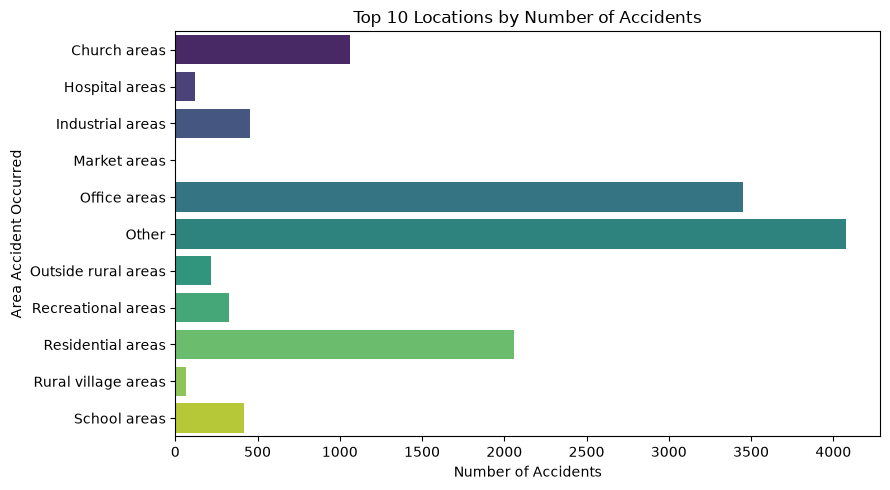

In [53]:
# Visual: top 10 accident locations
plt.figure(figsize=(9,5))
sns.barplot(x=location_table["Accident_Count"], y=location_table.index, palette="viridis")
plt.title("Top 10 Locations by Number of Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Area Accident Occurred")
plt.tight_layout()
plt.show()

Q3 : ACCIDENTS BY HOUR OF DAY 

In [54]:
# Extract hour from Time, then group + aggregate (count) by hour
df2["Hour"] = df2["Time"].apply(lambda t: t.hour if pd.notna(t) else np.nan)

hourly_counts = (df2.groupby("Hour", observed=True)
                  .size()
                  .sort_values(ascending=False))

hourly_table = hourly_counts.rename("Accident_Count").to_frame()
hourly_table.head(10)

,Accident_Count
Hour,
17,1228
18,956
16,921
15,874
8,828
13,772
19,708
12,691
14,639


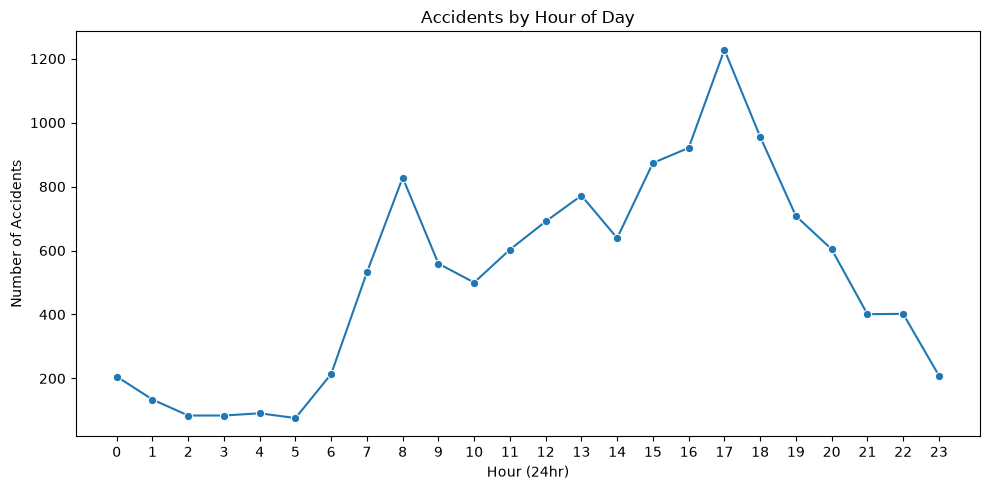

In [55]:
# Visual: accidents across all 24 hours, in time order (not sorted by count)
plt.figure(figsize=(10,5))
sns.lineplot(x=hourly_counts.sort_index().index, y=hourly_counts.sort_index().values, marker="o")
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour (24hr)")
plt.ylabel("Number of Accidents")
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

Q4: WHICH DAYS OF THE WEEK HAVE THE HIGHEST ACCIDENT FREQUENCY 

In [56]:
# value_counts on an ordered categorical column
day_counts = df2["Day_of_week"].value_counts().sort_values(ascending=False)
day_table = day_counts.rename("Accident_Count").to_frame()
day_table

,Accident_Count
Day_of_week,
Friday,3707
Thursday,1851
Wednesday,1840
Tuesday,1770
Monday,1681
Sunday,1467


C:\Users\User\AppData\Local\Temp\ipykernel_11708\702549123.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_table.index, y=day_table["Accident_Count"], order=day_table.index, palette="mako")


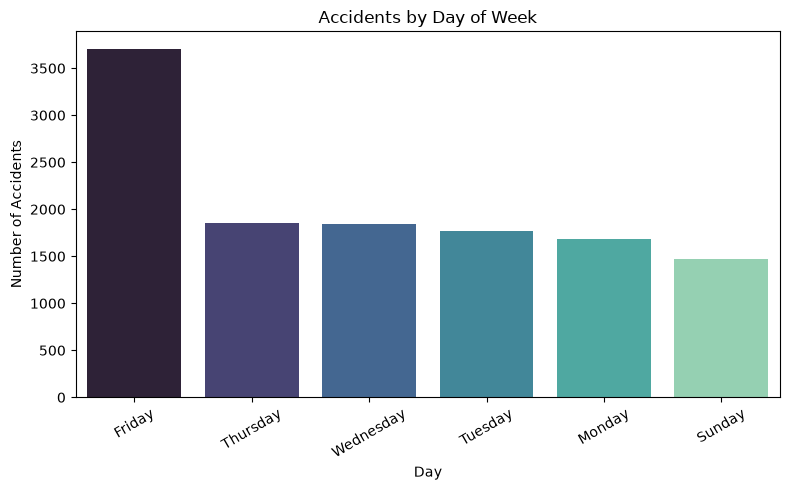

In [57]:
plt.figure(figsize=(8,5))
sns.barplot(x=day_table.index, y=day_table["Accident_Count"], order=day_table.index, palette="mako")
plt.title("Accidents by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Q5: WHAT ARE THE LEADING CAUSES OF ACCIDENTS 

In [58]:
cause_counts = (df2["Cause_of_accident"]
                 .value_counts()
                 .sort_values(ascending=False))

cause_table = cause_counts.head(10).rename("Accident_Count").to_frame()
cause_table

,Accident_Count
Cause_of_accident,
No distancing,2288
Changing lane to the right,1808
Changing lane to the left,1473
Driving carelessly,1402
No priority to vehicle,1207
Moving Backward,1137
No priority to pedestrian,721
Other,456
Overtaking,430


C:\Users\User\AppData\Local\Temp\ipykernel_11708\2477676505.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cause_table["Accident_Count"], y=cause_table.index, palette="rocket")


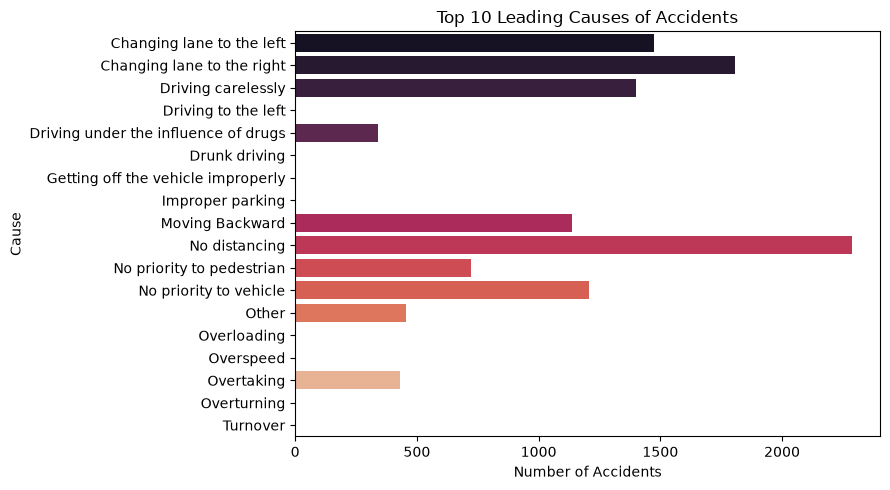

In [59]:
plt.figure(figsize=(9,5))
sns.barplot(x=cause_table["Accident_Count"], y=cause_table.index, palette="rocket")
plt.title("Top 10 Leading Causes of Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Cause")
plt.tight_layout()
plt.show()

Q6: WHAT WEATHER CONDITIONS ARE ASSSOCIATED WITH ACCIDENTS ?

In [62]:
weather_counts = df2["Weather_conditions"].value_counts().sort_values(ascending=False)
weather_table = weather_counts.rename("Accident_Count").to_frame()
weather_table

,Accident_Count
Weather_conditions,
Normal,10355
Rain,1331
Other,296
Cloudy,125
Windy,98
Snow,61
Rain & Wind,40
Fog or mist,10


In [63]:
# Grouping + aggregation: severity breakdown within each weather condition
weather_severity = (df2.groupby("Weather_conditions", observed=True)["Accident_severity"]
                     .value_counts()
                     .unstack(fill_value=0))
weather_severity

Accident_severity,Slight Injury,Serious Injury,Fatal Injury
Weather_conditions,,,
Cloudy,117,8,0
Fog or mist,9,1,0
Normal,8830,1525,0
Other,268,28,0
Rain,1173,158,0
Rain & Wind,38,2,0
Snow,56,5,0
Windy,82,16,0


Q7: WHAT IS THE DISTRIBUTION OFACCIDENT SEVERITY

In [64]:
# value_counts with percentages (summary statistic)
severity_counts = df2["Accident_severity"].value_counts()
severity_percent = (severity_counts / severity_counts.sum() * 100).round(2)

severity_table = pd.DataFrame({
    "Count": severity_counts,
    "Percentage": severity_percent
})
severity_table

,Count,Percentage
Accident_severity,,
Slight Injury,10573,85.85
Serious Injury,1743,14.15
Fatal Injury,0,0.00


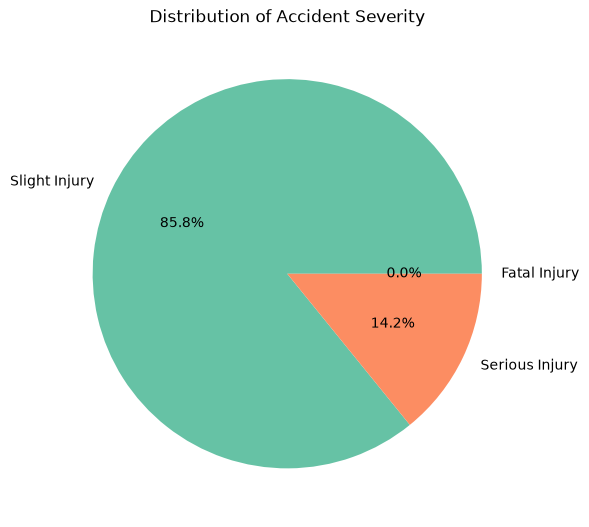

In [65]:
plt.figure(figsize=(6,6))
plt.pie(severity_table["Count"], labels=severity_table.index, autopct="%1.1f%%",
        colors=sns.color_palette("Set2"))
plt.title("Distribution of Accident Severity")
plt.tight_layout()
plt.show()

Q8. Which vehicle types are most involved in accidents?

In [66]:
vehicle_counts = (df2["Type_of_vehicle"]
                   .value_counts()
                   .sort_values(ascending=False))

vehicle_table = vehicle_counts.head(10).rename("Accident_Count").to_frame()
vehicle_table

,Accident_Count
Type_of_vehicle,
Automobile,4155
Lorry (41-100Q),2186
Other,1208
Pick up upto 10Q,811
Public (12 seats),711
Stationwagen,687
Lorry (11-40Q),541
Public (13-45 seats),532
Public (> 45 seats),404


C:\Users\User\AppData\Local\Temp\ipykernel_11708\2040596808.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vehicle_table["Accident_Count"], y=vehicle_table.index, palette="flare")


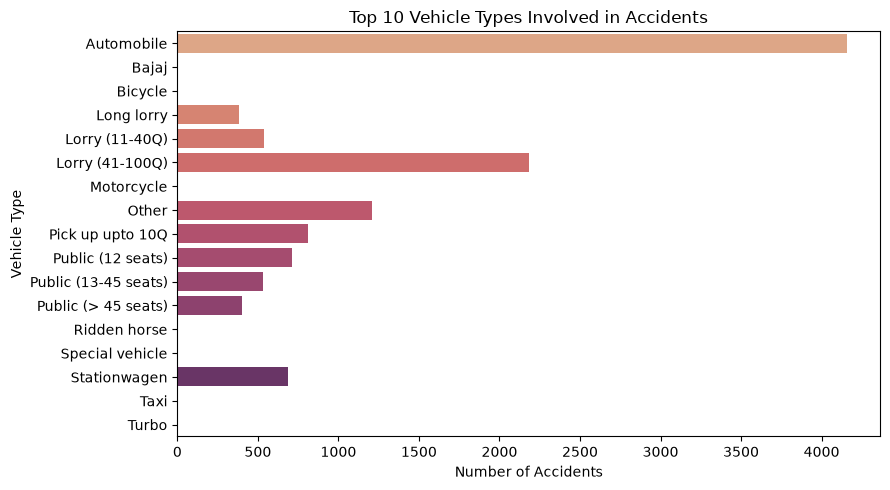

In [67]:
plt.figure(figsize=(9,5))
sns.barplot(x=vehicle_table["Accident_Count"], y=vehicle_table.index, palette="flare")
plt.title("Top 10 Vehicle Types Involved in Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Vehicle Type")
plt.tight_layout()
plt.show()

Q9. Which road users are most affected?

In [68]:
# Filtering example: isolate only fatal-injury casualties
fatal_casualties = df2[df2["Casualty_severity_label"] == "Fatal Injury"]

print(f"Total fatal-injury casualty records: {len(fatal_casualties)}")

# value_counts on who is affected (sex + age band of casualty)
sex_counts = df2["Sex_of_casualty"].value_counts()
age_counts = df2["Age_band_of_casualty"].value_counts().sort_index()

print("\nCasualties by sex:")
print(sex_counts)
print("\nCasualties by age band:")
print(age_counts)

Total fatal-injury casualty records: 26

Casualties by sex:
Sex_of_casualty
Male           5253
No Casualty    4443
Female         2620
Name: count, dtype: int64

Casualties by age band:
Age_band_of_casualty
Under 18       1279
18-30          3145
31-50          2455
Over 51         994
No Casualty    4443
Name: count, dtype: int64


In [69]:
# Grouping + aggregation: casualty severity breakdown by age band
age_severity = (df2.groupby("Age_band_of_casualty", observed=True)["Casualty_severity_label"]
                 .value_counts()
                 .unstack(fill_value=0))
age_severity

Casualty_severity_label,Fatal Injury,Serious Injury,Slight Injury,No Casualty
Age_band_of_casualty,,,,
Under 18,7,143,1129,0
18-30,5,275,2865,0
31-50,4,214,2237,0
Over 51,10,139,845,0
No Casualty,0,0,0,4443
